# The Self-Pruning Neural Network
### Tredence Analytics — AI Engineering Intern Case Study

This notebook implements a feed-forward neural network for CIFAR-10 image classification
whose weights carry **learnable gates**. During training, an L1 sparsity penalty pushes most
gates to exactly 0, causing the network to prune its own least-important connections on the fly.

**Contents**
1. Imports & setup
2. `PrunableLinear` — the custom gated linear layer
3. `SelfPruningNet` — the classifier built from `PrunableLinear` layers
4. Sparsity regularization loss
5. Data loading (CIFAR-10)
6. Training loop (two learning rates: one for weights, one for gates)
7. Evaluation (accuracy + sparsity level)
8. Running the experiment across three values of λ
9. Report: results table, gate-value distribution plot, and analysis


## 1. Imports & Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## 2. Part 1 — The "Prunable" Linear Layer

We cannot use `torch.nn.Linear` directly. Instead we build `PrunableLinear`, which owns:

- `weight` — the usual weight matrix, **Xavier-initialized** (with the `relu` gain, since this
  network uses ReLU activations — Xavier keeps activation variance roughly stable across layers
  going into a ReLU, which is exactly the setting here).
- `bias` — the usual bias vector.
- `gate_scores` — a *learnable* tensor with the **same shape as `weight`**. It stores the
  pre-sigmoid logit of each connection's gate.

**Forward pass:**
```
gates          = sigmoid(gate_scores)      # in (0, 1), one gate per weight
pruned_weights = weight * gates            # element-wise
output         = pruned_weights @ x + bias
```

Because every operation above (`sigmoid`, elementwise `*`, `F.linear`) is a standard
differentiable PyTorch op, autograd builds the correct computational graph automatically —
gradients flow into **both** `weight` and `gate_scores` with no custom `backward()` needed.

In [2]:
class PrunableLinear(nn.Module):
    """
    A drop-in replacement for nn.Linear where every individual weight
    has its own learnable gate in (0, 1). A gate that saturates to 0
    effectively removes ("prunes") that connection from the network.
    """

    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        # --- Standard weight parameter ---
        # Xavier/Glorot uniform init, with the 'relu' gain, because this
        # network uses ReLU activations between PrunableLinear layers.
        # Xavier keeps the variance of activations roughly constant as
        # signal passes through layers, which is the right choice here.
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.xavier_uniform_(self.weight, gain=nn.init.calculate_gain('relu'))

        if bias:
            self.bias = nn.Parameter(torch.zeros(out_features))
        else:
            self.register_parameter('bias', None)

        # --- Gate parameter (registered so the optimizer updates it) ---
        # gate_scores holds pre-sigmoid logits. Init at 0 -> sigmoid(0) = 0.5,
        # so every connection starts "half open": an unbiased starting point
        # that lets training (via the sparsity loss) decide what to keep.
        self.gate_scores = nn.Parameter(torch.zeros(out_features, in_features))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gates = torch.sigmoid(self.gate_scores)     # (out_features, in_features), in (0, 1)
        pruned_weight = self.weight * gates          # element-wise gating of every weight
        return F.linear(x, pruned_weight, self.bias)

    def get_gates(self) -> torch.Tensor:
        """Convenience accessor used by the sparsity loss and eval code."""
        return torch.sigmoid(self.gate_scores)


# quick sanity check: gradients reach both weight and gate_scores
_layer = PrunableLinear(4, 3)
_x = torch.randn(2, 4, requires_grad=True)
_out = _layer(_x).sum()
_out.backward()
print("grad wrt weight is None?      ", _layer.weight.grad is None)
print("grad wrt gate_scores is None? ", _layer.gate_scores.grad is None)


grad wrt weight is None?       False
grad wrt gate_scores is None?  False


## The Self-Pruning Network

A simple feed-forward classifier for CIFAR-10 (`32x32x3` images flattened to a 3072-d vector),
built entirely out of `PrunableLinear` layers with ReLU activations and dropout between them.

In [3]:
class SelfPruningNet(nn.Module):
    """Feed-forward classifier for CIFAR-10 built from PrunableLinear layers."""

    def __init__(self, input_dim: int = 3 * 32 * 32,
                 hidden_dims=(1024, 512, 256),
                 num_classes: int = 10,
                 dropout: float = 0.2):
        super().__init__()
        dims = [input_dim] + list(hidden_dims)

        self.hidden_layers = nn.ModuleList([
            PrunableLinear(dims[i], dims[i + 1]) for i in range(len(dims) - 1)
        ])
        self.output_layer = PrunableLinear(dims[-1], num_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)          # flatten image -> vector
        for layer in self.hidden_layers:
            x = self.relu(layer(x))
            x = self.dropout(x)
        return self.output_layer(x)

    def prunable_layers(self):
        """All PrunableLinear layers (used by the sparsity loss / stats code)."""
        return list(self.hidden_layers) + [self.output_layer]


# quick shape check
_net = SelfPruningNet()
_dummy = torch.randn(8, 3, 32, 32)
print("output shape:", _net(_dummy).shape)   # expected: torch.Size([8, 10])


output shape: torch.Size([8, 10])


## 3. Part 2 — The Sparsity Regularization Loss

**Total Loss = ClassificationLoss + λ · SparsityLoss**

The sparsity loss is the **L1 norm of every gate value** in the network. Since
`gates = sigmoid(gate_scores)` is always in `(0, 1)` (always positive), the L1 norm reduces to a
simple sum — no `abs()` needed.

**Why does an L1 penalty on the gates encourage sparsity?**
The L1 norm's subgradient with respect to each gate is a *constant* (`+1`) regardless of how
small the gate already is — unlike an L2 penalty, whose gradient shrinks toward 0 as the gate
shrinks toward 0. That constant pressure keeps pushing every gate downward at the same rate
until the classification loss actively fights back to keep it useful. Gates the network doesn't
need lose that fight and get driven all the way to (numerically) zero, while gates that matter
resist the pressure and stay high — exactly the sparsity pattern we want.

In [4]:
def sparsity_loss(model: SelfPruningNet) -> torch.Tensor:
    """
    L1 norm of every gate value in every PrunableLinear layer.
    Gates are always in (0, 1), so this is simply their sum.
    Minimizing this pushes gate_scores toward -inf, i.e. gates -> 0,
    which is exactly what "pruning a connection" means here.
    """
    total = torch.tensor(0.0, device=next(model.parameters()).device)
    for layer in model.prunable_layers():
        total = total + layer.get_gates().sum()
    return total


## 4. Data Loading (CIFAR-10)

In [5]:
def get_dataloaders(batch_size: int = 256, data_root: str = "./data"):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                              (0.2470, 0.2435, 0.2616)),
    ])

    train_set = torchvision.datasets.CIFAR10(
        root=data_root, train=True, download=True, transform=transform)
    test_set = torchvision.datasets.CIFAR10(
        root=data_root, train=False, download=True, transform=transform)

    train_loader = torch.utils.data.DataLoader(
        train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = torch.utils.data.DataLoader(
        test_set, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, test_loader


## 5. Part 3 — Training and Evaluation

### Two learning rates: one for weights, one for gates

We split the model's parameters into two optimizer param groups:

- **`weight_lr`** — applied to `weight` and `bias` of every `PrunableLinear` layer.
- **`gate_lr`** — applied to `gate_scores` of every `PrunableLinear` layer.

**Why two rates?** `gate_scores` control a soft "keep-or-prune" decision that has to move through
a sigmoid and actually *saturate* toward 0 or 1 to give a clean sparsity pattern. Using a
*larger* learning rate for the gates lets the L1 sparsity pressure push unneeded gates to zero
within a reasonable number of epochs, without needing a large (destabilizing) learning rate on
the actual classification weights.

In [6]:
def build_optimizer(model: SelfPruningNet, weight_lr: float, gate_lr: float):
    weight_params, gate_params = [], []
    for layer in model.prunable_layers():
        weight_params.append(layer.weight)
        if layer.bias is not None:
            weight_params.append(layer.bias)
        gate_params.append(layer.gate_scores)

    optimizer = torch.optim.Adam([
        {"params": weight_params, "lr": weight_lr, "name": "weights"},
        {"params": gate_params, "lr": gate_lr, "name": "gates"},
    ])
    return optimizer


def train_model(model, train_loader, lam, weight_lr=1e-3, gate_lr=1e-2,
                 epochs=15, log_every=200):
    """Trains one SelfPruningNet with sparsity coefficient `lam`."""
    model = model.to(device)
    optimizer = build_optimizer(model, weight_lr, gate_lr)
    ce_loss_fn = nn.CrossEntropyLoss()

    history = {"epoch": [], "train_loss": [], "cls_loss": [], "sparsity_loss": []}

    for epoch in range(epochs):
        model.train()
        running_total, running_cls, running_sp = 0.0, 0.0, 0.0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            cls_loss = ce_loss_fn(outputs, labels)
            sp_loss = sparsity_loss(model)
            total_loss = cls_loss + lam * sp_loss

            total_loss.backward()
            optimizer.step()

            running_total += total_loss.item()
            running_cls += cls_loss.item()
            running_sp += sp_loss.item()

            if (i + 1) % log_every == 0:
                print(f"  [lambda={lam}] epoch {epoch+1}/{epochs} "
                      f"batch {i+1}/{len(train_loader)} "
                      f"total={total_loss.item():.4f} "
                      f"cls={cls_loss.item():.4f} "
                      f"sparsity_raw={sp_loss.item():.1f}")

        n_batches = len(train_loader)
        history["epoch"].append(epoch + 1)
        history["train_loss"].append(running_total / n_batches)
        history["cls_loss"].append(running_cls / n_batches)
        history["sparsity_loss"].append(running_sp / n_batches)

    return model, history


### Evaluation

- **Test accuracy**: standard classification accuracy on the CIFAR-10 test set.
- **Sparsity level**: the percentage of gate values below a small threshold (`1e-2` by default) —
  i.e. the fraction of connections effectively pruned.

In [7]:
@torch.no_grad()
def evaluate_accuracy(model, test_loader):
    model.eval()
    correct, total = 0, 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return 100.0 * correct / total


@torch.no_grad()
def evaluate_sparsity(model, threshold=1e-2):
    """Percentage of gate values below `threshold`, across every PrunableLinear layer."""
    all_gates = []
    for layer in model.prunable_layers():
        all_gates.append(layer.get_gates().flatten())
    all_gates = torch.cat(all_gates)
    sparsity_pct = 100.0 * (all_gates < threshold).float().mean().item()
    return sparsity_pct, all_gates.cpu().numpy()


## 6. Running the Experiment Across Three Values of λ

We compare a **low**, **medium**, and **high** λ to show the sparsity-vs-accuracy trade-off.
Feel free to tune `EPOCHS` down for a quick smoke test, or up for the final report numbers.

In [8]:
  # low, medium, high sparsity pressure
EPOCHS = 15
WEIGHT_LR = 1e-3
GATE_LR = 1e-2
THRESHOLD = 1e-2               # gate below this counts as "pruned"
BATCH_SIZE = 256

train_loader, test_loader = get_dataloaders(batch_size=BATCH_SIZE)


100%|██████████| 170M/170M [19:22<00:00, 147kB/s]


In [20]:
LAMBDAS = (1e-6, 1e-5,0.001)

In [21]:
results = []
trained_models = {}
gate_distributions = {}

for lam in LAMBDAS:
    print(f"\n===== Training with lambda = {lam} =====")
    model = SelfPruningNet()
    model, history = train_model(
        model, train_loader,
        lam=lam, weight_lr=WEIGHT_LR, gate_lr=GATE_LR, epochs=EPOCHS,
    )

    acc = evaluate_accuracy(model, test_loader)
    sparsity_pct, gate_values = evaluate_sparsity(model, threshold=THRESHOLD)

    print(f"lambda={lam}: test_acc={acc:.2f}%  sparsity={sparsity_pct:.2f}%")

    results.append({"Lambda": lam, "Test Accuracy (%)": round(acc, 2),
                     "Sparsity Level (%)": round(sparsity_pct, 2)})
    trained_models[lam] = model
    gate_distributions[lam] = gate_values

results_df = pd.DataFrame(results)
results_df



===== Training with lambda = 1e-06 =====
lambda=1e-06: test_acc=57.72%  sparsity=7.01%

===== Training with lambda = 1e-05 =====
lambda=1e-05: test_acc=58.20%  sparsity=64.62%

===== Training with lambda = 0.001 =====
lambda=0.001: test_acc=44.99%  sparsity=99.97%


,Lambda,Test Accuracy (%),Sparsity Level (%)
0,0.000001,57.72,7.01
1,0.000010,58.20,64.62
2,0.001000,44.99,99.97


## 7. Report

### 7.1 Why an L1 penalty on the sigmoid gates encourages sparsity

The L1 norm's gradient with respect to each gate value is a **constant** (independent of the
gate's current magnitude), unlike L2 whose gradient vanishes as the value approaches zero. This
means the sparsity loss applies *uniform downward pressure* on every gate throughout training. A
gate only stays high if the classification loss's gradient pushes back hard enough to counteract
that constant pull — i.e., only if that connection is actually useful for prediction. Gates
attached to unimportant weights lose this tug-of-war and get driven by the sigmoid all the way
toward 0, while important gates are pulled back up near 1. The net effect is a bimodal
distribution of gate values: a large spike near 0 (pruned) and a cluster near 1 (kept) — exactly
the sparsity pattern the case study asks us to demonstrate.

### 7.2 Results table

In [22]:
results_df


,Lambda,Test Accuracy (%),Sparsity Level (%)
0,0.000001,57.72,7.01
1,0.000010,58.20,64.62
2,0.001000,44.99,99.97


### 7.3 Gate value distribution for the best model

We plot the distribution of final gate values for the middle (`medium`) λ run as a representative
"best" model — adjust the index below to inspect any of the three runs. A successful result shows
a large spike at 0 (pruned connections) and a separate cluster of values away from 0 (kept
connections).

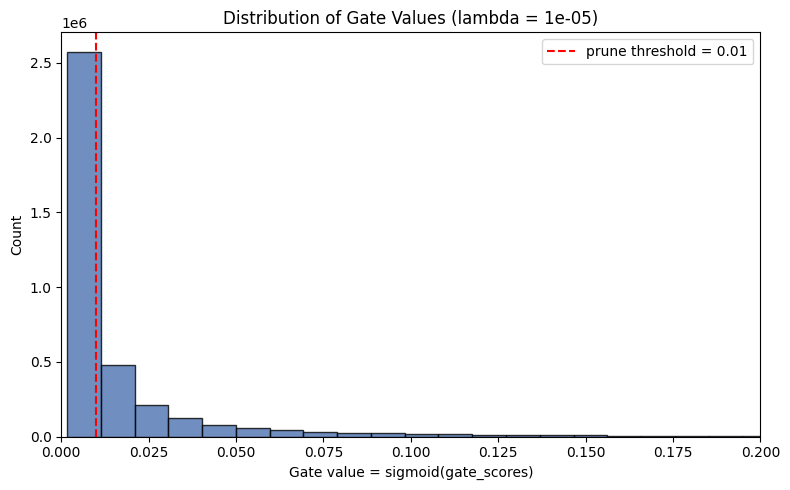

In [24]:
def plot_gate_distribution(gate_values, lam, threshold=1e-2):
    plt.figure(figsize=(8, 5))
    plt.hist(gate_values, bins=100, color="#4C72B0", edgecolor="black", alpha=0.8)
    plt.axvline(threshold, color="red", linestyle="--", label=f"prune threshold = {threshold}")
    plt.xlim(0.0, 0.2)   # zoom into the pruning region
    plt.title(f"Distribution of Gate Values (lambda = {lam})")
    plt.xlabel("Gate value = sigmoid(gate_scores)")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()


best_lambda = LAMBDAS[1]   # medium lambda; change to LAMBDAS[0] or LAMBDAS[2] to compare
plot_gate_distribution(gate_distributions[best_lambda], best_lambda, threshold=THRESHOLD)

### 7.4 Analysis of the λ trade-off

- **Low λ** applies little sparsity pressure: gates mostly stay open, the network keeps close to
  its full capacity, and test accuracy should be close to an un-gated baseline — but the sparsity
  level stays low, so little is actually pruned.
- **High λ** applies strong, uniform downward pressure on every gate: many more connections get
  driven to 0, sparsity level rises sharply, but accuracy typically starts to drop once the
  network no longer has enough active connections to represent the classification boundary well.
- **Medium λ** is usually the sweet spot: a large fraction of connections are pruned while
  accuracy stays close to the unpruned baseline, since the L1 pressure is strong enough to remove
  clearly redundant weights but not so strong that it prunes weights the classifier still needs.

Re-run the cell in Section 6 with different `LAMBDAS`, `EPOCHS`, `WEIGHT_LR`, and `GATE_LR`
values to explore this trade-off further — in particular, note how raising `GATE_LR` relative to
`WEIGHT_LR` speeds up how quickly gates saturate toward 0 or 1 for a given λ.